In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import metrics

In [2]:
import pickle

NUM_CLASSES = 5

with open('test_pred.pickle', 'rb') as file:
  test_pred = pickle.load(file)

test_pred_onehot = pd.DataFrame(np.eye(NUM_CLASSES)[test_pred])
test_pred = pd.DataFrame(test_pred)

In [3]:
stage_dict = {0:'Arousal', 1:'NREM1', 2:'NREM2', 3:'NREM3', 4:'REM'}
test_labels = pd.read_pickle('TEST_LABELS.xz')
test_labels_one_hot = pd.DataFrame(np.eye(5)[test_labels.values.reshape(1000).astype(int)])
acc=0
for i, j in enumerate(test_pred):
  if test_labels['Label'][i]==j:
    acc+=1
print(acc/len(test_labels))

0.0


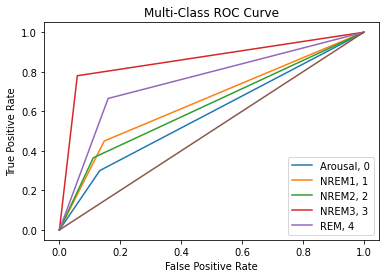

In [4]:
fpr = {}
tpr = {}
roc_auc = {}
for i in range(5):
  fpr[i], tpr[i], _ = metrics.roc_curve(test_labels_one_hot.iloc[:, i], test_pred_onehot.iloc[:, i])
  roc_auc[i] = metrics.auc(fpr[i], tpr[i])
  plt.plot(fpr[i], tpr[i], label = stage_dict[i] + ', ' + str(i))
plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend()
plt.show()

fpr["micro"], tpr["micro"], _ = metrics.roc_curve(test_labels_one_hot.values.ravel(), test_pred_onehot.values.ravel())
roc_auc = metrics.auc(fpr["micro"], tpr["micro"])

In [5]:
test_pred.iloc[0]

0    3
Name: 0, dtype: int64

In [7]:
y_true = []
y_pred = []
test_predict = test_pred_onehot.idxmax(axis=1)
for i in range(test_pred.shape[0]):
    if test_predict.iloc[i]==0: y_pred.append(1)
    else: y_pred.append(-1)
    if test_labels.values[i]==0: y_true.append(1)
    else: y_true.append(-1)
mcc = metrics.matthews_corrcoef(y_true, y_pred)

In [8]:
print(roc_auc, mcc)

0.6950000000000001 0.18006849441114053
